In [4]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import pyro
import pyro.distributions as distr

### 4.1 Why Normal Distributions are normal

This section demonstrates how many different distributions data can result in looking Normal (Gaussian)

#### 4.1.1 Normal by addition

In [7]:
def runif(n: int, low: float, high: float):
    """Recreation of runiffunction using PyTorch and Pyro"""
    m = distr.Uniform(low=low, high=high)
    return m.sample((n,))

In [51]:
pos = []

for _ in range(1000):
    pos.append(sum(runif(16, -1, 1)).item())


<Axes: ylabel='Density'>

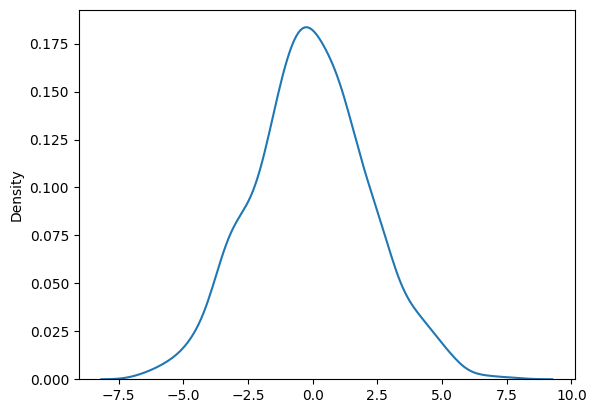

In [53]:
import seaborn as sns

sns.kdeplot(x = pos)

#### 4.1.2 Normal by multiplication

In [ ]:
import math

math.prod(1 + runif(12, 0, 0.1))

tensor(1.8760)

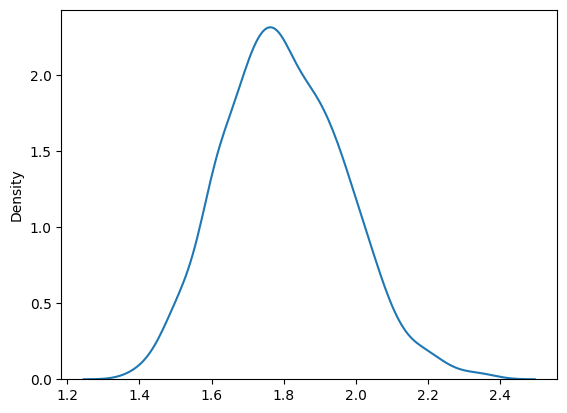

In [63]:
growth = []

for _ in range(1000):
    growth.append(math.prod( 1 + runif(12, 0, 0.1)).item())

sns.kdeplot(x=growth);

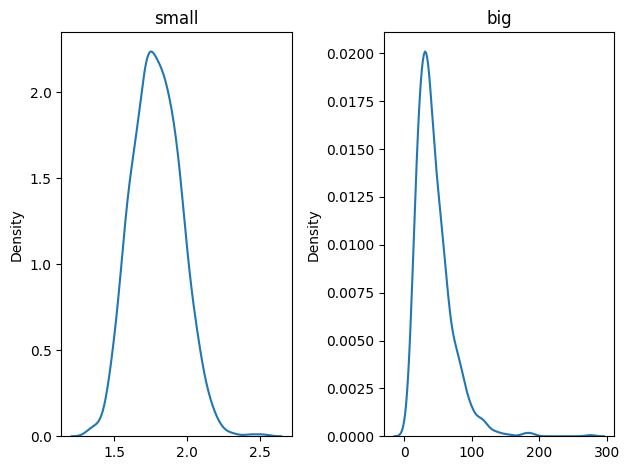

In [73]:
big = []
small = []
for _ in range(1000):
    big.append(math.prod( 1 + runif(12, 0, 0.75)).item())
    small.append(math.prod( 1 + runif(12, 0, 0.1)).item())

fig, axs = plt.subplots(1, 2)

sns.kdeplot(x=small, ax=axs[0])
axs[0].set_title("small")
sns.kdeplot(x=big, ax=axs[1])
axs[1].set_title("big")

plt.tight_layout()
plt.show()

#### 4.1.3 Normal by log-multiplication

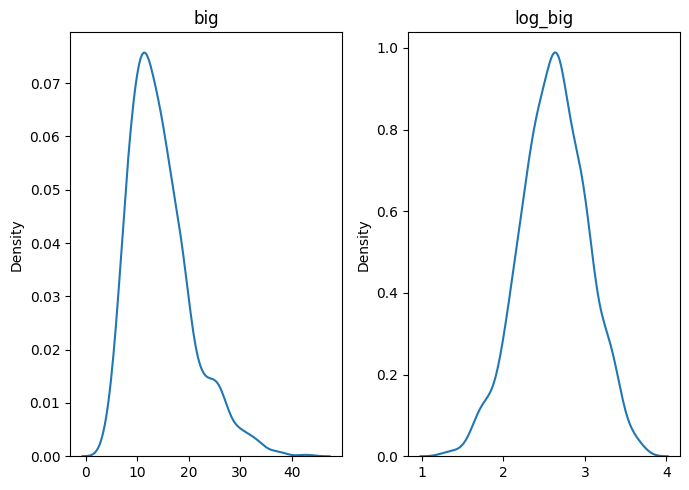

In [74]:
big = []
log_big = []
for _ in range(1000):
    big.append(math.prod( 1 + runif(12, 0, 0.5)).item())
    log_big.append(math.log(math.prod( 1 + runif(12, 0, 0.5)).item()))

fig, axs = plt.subplots(1, 2, figsize=(7,5))

sns.kdeplot(x=big, ax=axs[0])
axs[0].set_title("big")
sns.kdeplot(x=log_big, ax=axs[1])
axs[1].set_title("log_big")

plt.tight_layout()
plt.show()

#### 4.1.4 Using Gaussian distributions

Justifications for using Gaussian distribution:
 1. Ontological: 
     * World is full of Gaussian like data (approximately)
     * Processes (like measurement error, molecule velocities etc.) add together fluctuations - results in distribution of sums that have shed all information about the underlying process, aside from mean and spread
     * Consequence - statistical models based on Gaussian distributions cannot reliably identify micro-process
         * Can still do useful work
     * Gaussian is a member of a family of fundamental natural distributions known as the *exponential family* - this family populations our world
 2. Epistemological justification
     * Gaussian represents a particular state of ignorance - when all we know is mean and variance Guassian is most consistent with assumptions
     * Premised on *information theory* and *maximum entropy*

Overthinking: Gaussian Distribution
 * Probability distributions with discrete outcomes - *probability mass* - denoted with Pr
 * Probability distributions with continuous outcomes - *probability density* - denoted with p
     * Probability density is teh rate of change in cumulative probability
     * Density can be > 1 but area under the density function never exceeds 1. These areas are called *probability mass*

### 4.2 A language for describing models

Approach to language in abstract:
 1. First, we recognize a set of variables to work with. Some of these variables are obserable. We call these *data*. Others are unobservable things like rates and averages. These are called *parameters*
 2. We define each variable either in terms of the other variables or in terms of a probability distributions
 3. The combination of variables and their probability distributions defines a *joint generative model* that can be used both to simulate hypothetical observations as well as analyze real ones

After decisions are made, the model is summarized mathematically like:

$$ y_{i} \sim \text{Normal}(\mu_{i},\sigma) $$
$$ \mu_{i} = \beta x_{i} $$
$$ \beta \sim \text{Normal}(0, 10) $$
$$ \sigma \sim \text{Exponential}(1) $$
$$ x_{i} \sim \text{Normal}(0,1) $$

#### 4.2.1 Re-describing the globe tossing model

Model:

$$ W \sim \text{Binomial}(N, p) $$
$$ p \sim \text{Uniform}(0,1) $$

Where $W$ is the observed count of water, $N$ is the total number of tosses, and $p$ was the proportion of water on the globe. The text above can be read as:

The count $W$ is distributed binomially with sample size $N$ and probability $p$

The prior for $p$ is assumed to be uniform between zero and one

From this we also know all of the assumptions. For example the binomial distributions assumes independent samples.

In these models, the first line defines teh likelihood function used in Bayes' theorem. The other lines define priors. Both lines in this model are *STOCHASTIC*, as indicated by $\sim$. A stochastic relationship is just a mapping of a variable or parameter onto a distribution. 

Overthinking: From model definition to Bayes' Theorem

Using the model definition above we can define the posterior distribution as:

$$ \Pr(p|w,n) = \frac{\text{Binomial}(w|n,p)\text{Uniform}(p|0,1)}{\int\text{Binomial}(w|n,p)\text{Uniform}(p|0,1)dp}


### 4.3 Gaussian model of height

#### 4.3.1 The data

We will be using the `Howell1` data which are partial census data for the dobe area !Kung San, compiled from interviews conducted by Nancy Howell in teh late 1960s.

In [77]:
import pandas as pd

d = pd.read_csv('data/Howell1.csv', sep=';')
d

,height,weight,age,male
0,151.765,47.825606,63.0,1
1,139.700,36.485807,63.0,0
2,136.525,31.864838,65.0,0
3,156.845,53.041914,41.0,1
4,145.415,41.276872,51.0,0
...,...,...,...,...
539,145.415,31.127751,17.0,1
540,162.560,52.163080,31.0,1
541,156.210,54.062497,21.0,0
542,71.120,8.051258,0.0,1


In [79]:
d.describe()

,height,weight,age,male
count,544.000000,544.000000,544.000000,544.000000
mean,138.263596,35.610618,29.344393,0.472426
std,27.602448,14.719178,20.746888,0.499699
min,53.975000,4.252425,0.000000,0.000000
25%,125.095000,22.007717,12.000000,0.000000
50%,148.590000,40.057844,27.000000,0.000000
75%,157.480000,47.209005,43.000000,1.000000
max,179.070000,62.992589,88.000000,1.000000


Data comprises 544 individuals with recorded height (centimeters), weight (kilograms), age (years), and sex (0=female, 1=male)

For now we are just going to focus on height of adult individuals

In [ ]:
d2 = d[d['age'] >= 18].reset_index(drop=True)

#### 4.3.2 The model

The Model:

$ h_i \sim \text{Normal}(\mu, \sigma) $ [likelihood]

$ \mu \sim \text{Normal}(178, 20) $ [$\mu$ prior]

$ \sigma \sim \text{Uniform}(0, 50) $ [$\sigma$ prior]


Where $h$ refers to the list of heights, and the subscript $i$ means each individual element of the list. Some prior information has made it into these priors.

In general it is good to visualize the priors to assess the sense of the assumptions that are being made. It is also a good idea to conduct *PRIOR PREDICTIVE* simulations to assess what your choices of piror imply about the observable variables. This is done by sampling from the prior. 

Text(0.5, 1.0, 'sigma ~ Uniform(0, 50)')

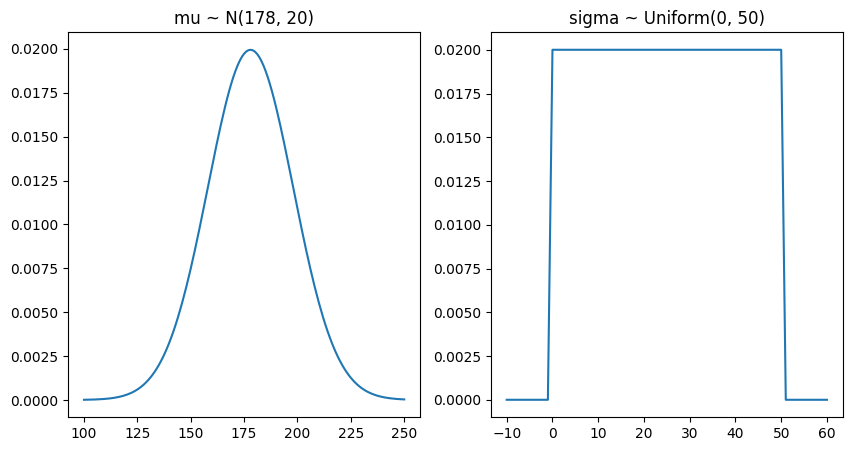

In [91]:
# Plot priors

from scipy.stats import norm, uniform

vals_mu = np.linspace(100, 250, num=250-100+1)
mu_prior = norm.pdf(vals, loc=178, scale=20)

vals_sigma = np.linspace(-10, 60, num=71)
sigma_prior = uniform.pdf(vals_sigma, loc=0, scale=50)

fig, axs = plt.subplots(1, 2, figsize=(10,5))

axs[0].plot(vals_mu, mu_prior, )
axs[0].set_title('mu ~ N(178, 20)')

axs[1].plot(vals_sigma, sigma_prior, )
axs[1].set_title('sigma ~ Uniform(0, 50)')

<Axes: ylabel='Density'>

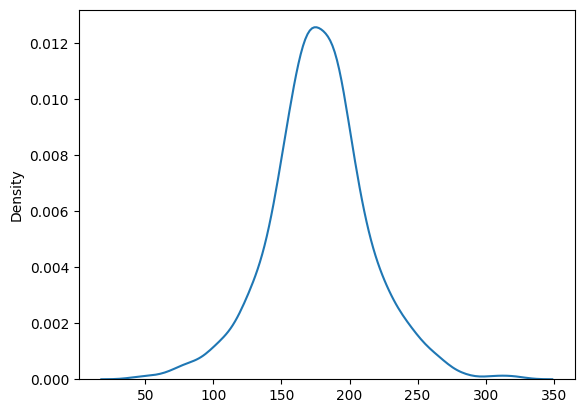

In [94]:
# Prior predictive simulation

sample_mu = norm.rvs(loc=178, scale=20, size=1000)
sample_sigma = uniform.rvs(loc=0, scale=50, size=1000)
prior_h = norm.rvs(loc=sample_mu, scale=sample_sigma, size=1000)

sns.kdeplot(prior_h)

Prior predictive simulation is very useful for assigning sensible priors. Note though that priors with large standard deviations are common in Bayesian models and they are not always sensible. In some cases this isn't harmless, but if the data are not sufficient then the posterior may not be accurate

In general:
 * Using scientific knowledge to build priors is not cheating
 * Important that the prior is not based off of the values in the observed data, only on what you know about teh data before you see it

In [85]:
vals_sigma = np.linspace(-10, 60, num=71)
vals_sigma

array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
         1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,  11.,
        12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,  22.,
        23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,
        34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,  44.,
        45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,  55.,
        56.,  57.,  58.,  59.,  60.])